# AI3I - NCAA March Mania 2025

Predicting the outcomes of March-Madness!

### Problem overview

Each season there are thousands of NCAA® basketball games played between Division I college basketball teams, culminating in March Madness®, the national championship men's and women's tournaments that run from mid-March until their championship games in early April. We have a large amount of historical data about college basketball games and teams, going back many years. Armed with this historical data, we explore it and develop our way of predicting March Madness® game outcomes.

### Dataset description

Our dataset contains men's and women's regular season and NCAA® tournament results with team box-score statistics for every game, from season 2003 until 2025. Each season, a team accessing the NCAA® tournament is assigned with a seed, which is used to create the matchups; a dataset with all the seeds of those teams that accessed the tournament is available.  
**For men's only**, ordinal rankings assigned from various ranking systems are available, from season 2003 onwards.

### Project's goal

The goal of the project is to use regular season results to create features for each team, and use such features to predict the outcomes of the NCAA® tournament. We will use data from season 2003-2024 as training/validation, and season 2025 to test our predictions.

### Evaluation metric

The competition rank solutions based on the **Brier score** (mean squared error between predicted probability and outcome):

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$$



In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import xgboost as xgb
import optuna
from sklearn.metrics import log_loss, brier_score_loss, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import UnivariateSpline

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999) # to visualize all the columns

## Data Loading

In [101]:
data_dir = "/Users/shariqansari/Downloads/march-machine-learning-mania-2026"

# M -> men's basketball
M_regular_results_df = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results_df = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds_df = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")
M_massey_ordinals_df = pd.read_csv(f"{data_dir}/MMasseyOrdinals.csv")

# W -> women's basketball 
W_regular_results_df = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results_df = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds_df = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

We tag each dataset with a `Category` column (0 = Men, 1 = Women) and concatenate Men's and Women's data into unified DataFrames. Training on both categories simultaneously gives the model more data and lets it learn shared basketball patterns.

In [102]:
category = {"Men":0, "Women":1}

M_regular_results_df["Category"] = category["Men"]
M_tourney_results_df["Category"] = category["Men"]
W_regular_results_df["Category"] = category["Women"]
W_tourney_results_df["Category"] = category["Women"]

In [103]:
regular_results_df = pd.concat([M_regular_results_df, W_regular_results_df])
tourney_results_df = pd.concat([M_tourney_results_df, W_tourney_results_df])
seeds_df = pd.concat([M_seeds_df, W_seeds_df])

## Data exploration

In [104]:
regular_results_df.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,Category
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20,0
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16,0
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23,0
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23,0
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14,0


Massey ordinals contains ranking assigned by external systems. It exists for men's competition only

In [105]:
M_massey_ordinals_df

,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260
...,...,...,...,...,...
5864996,2026,133,WLS,1477,318
5864997,2026,133,WLS,1478,303
5864998,2026,133,WLS,1479,287
5864999,2026,133,WLS,1480,293


Do we have nan values?

In [106]:
print("NaN values?")
print("")
print(f"Regular Season results: {any(regular_results_df.isna().any())}")
print(f"Tourney results:        {any(tourney_results_df.isna().any())}")
print(f"Ordinal rankings:       {any(M_massey_ordinals_df.isna().any())}")

NaN values?

Regular Season results: False
Tourney results:        False
Ordinal rankings:       False


Let's see the journey of a team during last season

In [107]:
season = 2025
team_id = 1104

r = regular_results_df[
    (regular_results_df["Season"]==season) & 
    ((regular_results_df["WTeamID"]==team_id) | (regular_results_df["LTeamID"]==team_id))]

t = tourney_results_df[
    (tourney_results_df["Season"]==season) & 
    ((tourney_results_df["WTeamID"]==team_id) | (tourney_results_df["LTeamID"]==team_id))]

r["Type"] = "regular season"
t["Type"] = "tournament"

rt = pd.concat([r,t])
rt["Outcome"] = np.where(rt["WTeamID"] == team_id, "win", "lose")

rt[["DayNum", "WScore", "LScore", "Type", "Outcome"]]

,DayNum,WScore,LScore,Type,Outcome
113241,0,110,54,regular season,win
113411,4,88,79,regular season,win
113547,7,72,64,regular season,win
113724,11,87,78,regular season,lose
113916,16,100,87,regular season,win
114219,22,85,80,regular season,win
114275,23,95,90,regular season,win
114447,26,83,81,regular season,lose
114563,30,94,79,regular season,win
114859,40,83,75,regular season,win


### Ranking stats
Seeds describe team's ranking (according to experts) based on their prior performance throughout the regular season. They are alphanumeric strings, with the first character determining the region of the team. An additional letter is added to distinguish teams belonging to the same region. We will use only the digits of the seed to represent their ranking.

NB: only tournament's teams are assigned with a seed

In [108]:
seeds_df[["Seed"]].drop_duplicates()

,Seed
0,W01
1,W02
2,W03
3,W04
4,W05
...,...
2551,Z10b
1670,Z12a
1671,Z12b
1769,X10a


Which seeds did our team have? Which average ordinal ranking?

In [109]:
seeds_df[(seeds_df["Season"]==season) & (seeds_df["TeamID"]==team_id)]

,Season,Seed,TeamID
2559,2025,W02,1104


Let's compute mean `OrdinalRank` across all ranking systems for team 1104 during season 2025, grouped by ranking day.

In [110]:
M_massey_ordinals_df[(M_massey_ordinals_df["Season"]==season) & (M_massey_ordinals_df["TeamID"]==team_id)].groupby("RankingDayNum")["OrdinalRank"].mean().reset_index().tail(5)

,RankingDayNum,OrdinalRank
14,107,4.173077
15,114,5.094340
16,121,4.981818
17,128,5.035714
18,133,5.553571


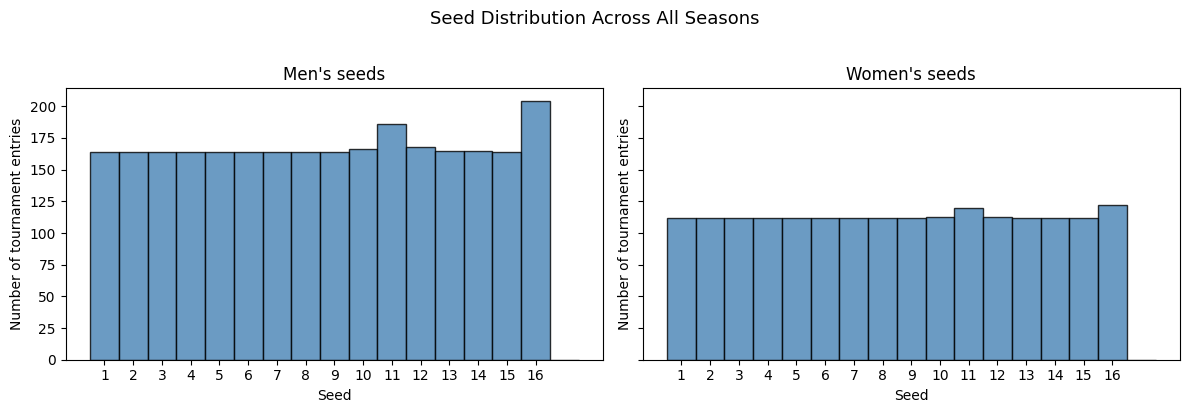

In [111]:
# distribution of numeric seeds across all seasons, for Men and Women
int_seeds_M = M_seeds_df['Seed'].map(lambda x: int(x[1:3]))
int_seeds_W = W_seeds_df['Seed'].map(lambda x: int(x[1:3]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, seeds, title in zip(axes, [int_seeds_M, int_seeds_W], ["Men's seeds", "Women's seeds"]):
    ax.hist(seeds, bins=range(1, 19), edgecolor='black', align='left', color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Seed')
    ax.set_ylabel('Number of tournament entries')
    ax.set_xticks(range(1, 17))
plt.suptitle('Seed Distribution Across All Seasons', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Some games do not end at the regular time and 1 or more OT (overtime) are played. This means that stats are collected for a longer time (higher scored points, rebounds, etc.)

<Axes: xlabel='NumOT'>

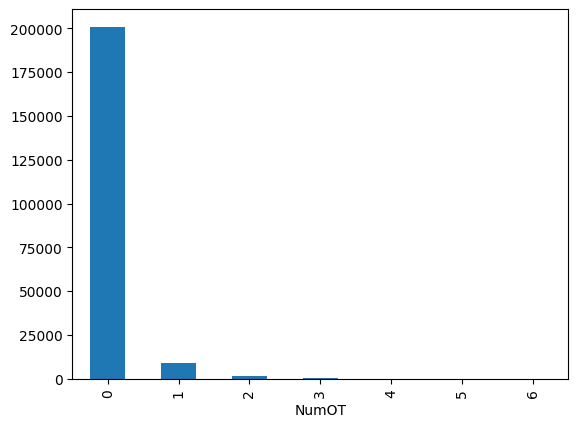

In [112]:
regular_results_df["NumOT"].value_counts().plot(kind="bar")

Is winning at home easier than winning away?

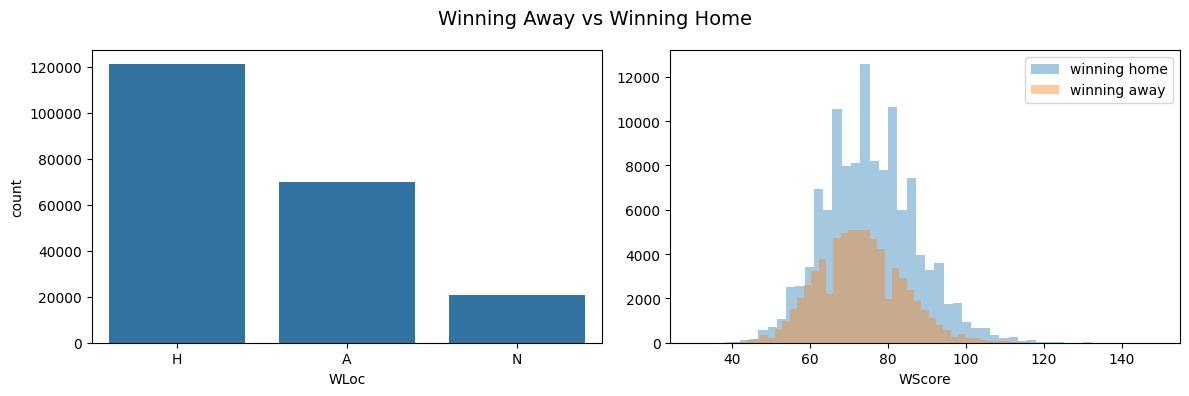

In [113]:
s1 = regular_results_df[regular_results_df["WLoc"]== "H"]["WScore"]
s2 = regular_results_df[regular_results_df["WLoc"]== "A"]["WScore"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

seaborn.barplot(x=regular_results_df["WLoc"].value_counts().index, 
                y=regular_results_df["WLoc"].value_counts(),
                ax=axes[0])
seaborn.distplot(s1, label="winning home", kde=False, ax=axes[1])
seaborn.distplot(s2, label="winning away", kde=False, ax=axes[1])

axes[1].legend()
plt.suptitle('Winning Away vs Winning Home', fontsize=14)
plt.tight_layout()
plt.show()

we can take into account the home advantage by correcting the raw scores with the mean differences. 

In [114]:
home_score_mean = s1.mean()
away_score_mean = s2.mean()
home_advantage = (home_score_mean - away_score_mean)/2

print(f"The mean score when winning home is: {home_score_mean}")
print(f"The mean score when winning away is: {away_score_mean}")
print("")
print(f"Mean home advantage points is: {home_score_mean - away_score_mean}")

The mean score when winning home is: 75.3961703532519
The mean score when winning away is: 72.77674365325964

Mean home advantage points is: 2.6194266999922604


Stats percentages might capture better the average performance of a team throughout a season with respect to raw stats

In [115]:
rr = regular_results_df.copy()

rr["WFG%"] = rr["WFGM"]/rr["WFGA"]
rr["WFG%3"] = rr["WFGM3"]/rr["WFGA3"]
rr["WFT%"] = rr["WFTM"]/rr["WFTA"]

rr["LFG%"] = rr["LFGM"]/rr["LFGA"]
rr["LFG%3"] = rr["LFGM3"]/rr["LFGA3"]
rr["LFT%"] = rr["LFTM"]/rr["LFTA"]

columns_to_describe = ['WScore','LScore','WLoc','WFGM','WFGA','WFG%',
                       'WFGM3','WFGA3','WFG%3','WFTM','WFTA','WFT%','WOR',
                       'WDR','WAst','WTO','WStl','WBlk','WPF',
                       'LFGM','LFGA','LFG%','LFGM3','LFGA3','LFG%3',
                       'LFTM','LFTA','LFT%','LOR','LDR','LAst','LTO',
                       'LStl','LBlk','LPF']
winning_teams_columns = [c for c in columns_to_describe if c.startswith("W")]
losing_teams_columns = [c for c in columns_to_describe if c.startswith("L")]

In [116]:
rr[winning_teams_columns].describe()

,WScore,WFGM,WFGA,WFG%,WFGM3,WFGA3,WFG%3,WFTM,WFTA,WFT%,WOR,WDR,WAst,WTO,WStl,WBlk,WPF
count,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211702.000000,211716.000000,211716.000000,211688.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000
mean,74.347182,26.237209,57.166081,0.460710,6.963810,18.940973,0.365366,14.908954,20.851622,0.715244,10.973960,25.962469,14.838156,13.492216,7.672505,3.732968,16.683028
std,11.458923,4.821583,7.811166,0.068897,3.183975,6.366821,0.117219,6.112946,7.971070,0.118703,4.461546,5.090498,4.530240,4.464958,3.495792,2.417302,4.214254
min,30.000000,9.000000,26.000000,0.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,66.000000,23.000000,52.000000,0.413793,5.000000,14.000000,0.285714,11.000000,15.000000,0.642857,8.000000,22.000000,12.000000,10.000000,5.000000,2.000000,14.000000
50%,74.000000,26.000000,57.000000,0.459459,7.000000,19.000000,0.363636,14.000000,20.000000,0.722222,11.000000,26.000000,15.000000,13.000000,7.000000,3.000000,16.000000
75%,82.000000,29.000000,62.000000,0.508197,9.000000,23.000000,0.441176,19.000000,26.000000,0.800000,14.000000,29.000000,18.000000,16.000000,10.000000,5.000000,19.000000
max,149.000000,58.000000,113.000000,0.800000,30.000000,63.000000,1.000000,50.000000,67.000000,1.000000,45.000000,58.000000,45.000000,40.000000,36.000000,21.000000,42.000000


In [117]:
rr[losing_teams_columns].describe()

,LScore,LFGM,LFGA,LFG%,LFGM3,LFGA3,LFG%3,LFTM,LFTA,LFT%,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
count,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211709.000000,211716.000000,211716.000000,211581.000000,211716.00000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000
mean,61.307204,22.055338,57.335029,0.386048,5.734385,19.376311,0.292827,11.462143,16.826839,0.679926,10.68812,21.860960,11.232481,15.130113,6.462365,2.850262,18.797054
std,11.413701,4.498934,7.725899,0.067848,2.822170,6.359618,0.109315,5.248387,6.986135,0.138866,4.40488,4.704645,3.770125,5.044259,2.985238,2.033009,4.585103
min,11.000000,3.000000,25.000000,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,54.000000,19.000000,52.000000,0.339623,4.000000,15.000000,0.222222,8.000000,12.000000,0.600000,8.00000,19.000000,9.000000,12.000000,4.000000,1.000000,16.000000
50%,61.000000,22.000000,57.000000,0.385965,5.000000,19.000000,0.291667,11.000000,16.000000,0.687500,10.00000,22.000000,11.000000,15.000000,6.000000,3.000000,19.000000
75%,69.000000,25.000000,62.000000,0.431373,8.000000,23.000000,0.363636,15.000000,21.000000,0.772727,13.00000,25.000000,14.000000,18.000000,8.000000,4.000000,22.000000
max,144.000000,53.000000,111.000000,0.727273,25.000000,80.000000,1.000000,48.000000,65.000000,1.000000,38.00000,53.000000,34.000000,49.000000,26.000000,18.000000,47.000000


Let's plot some features distribution  

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**
- understand which features are better to plot (more on this later in the notebook!)

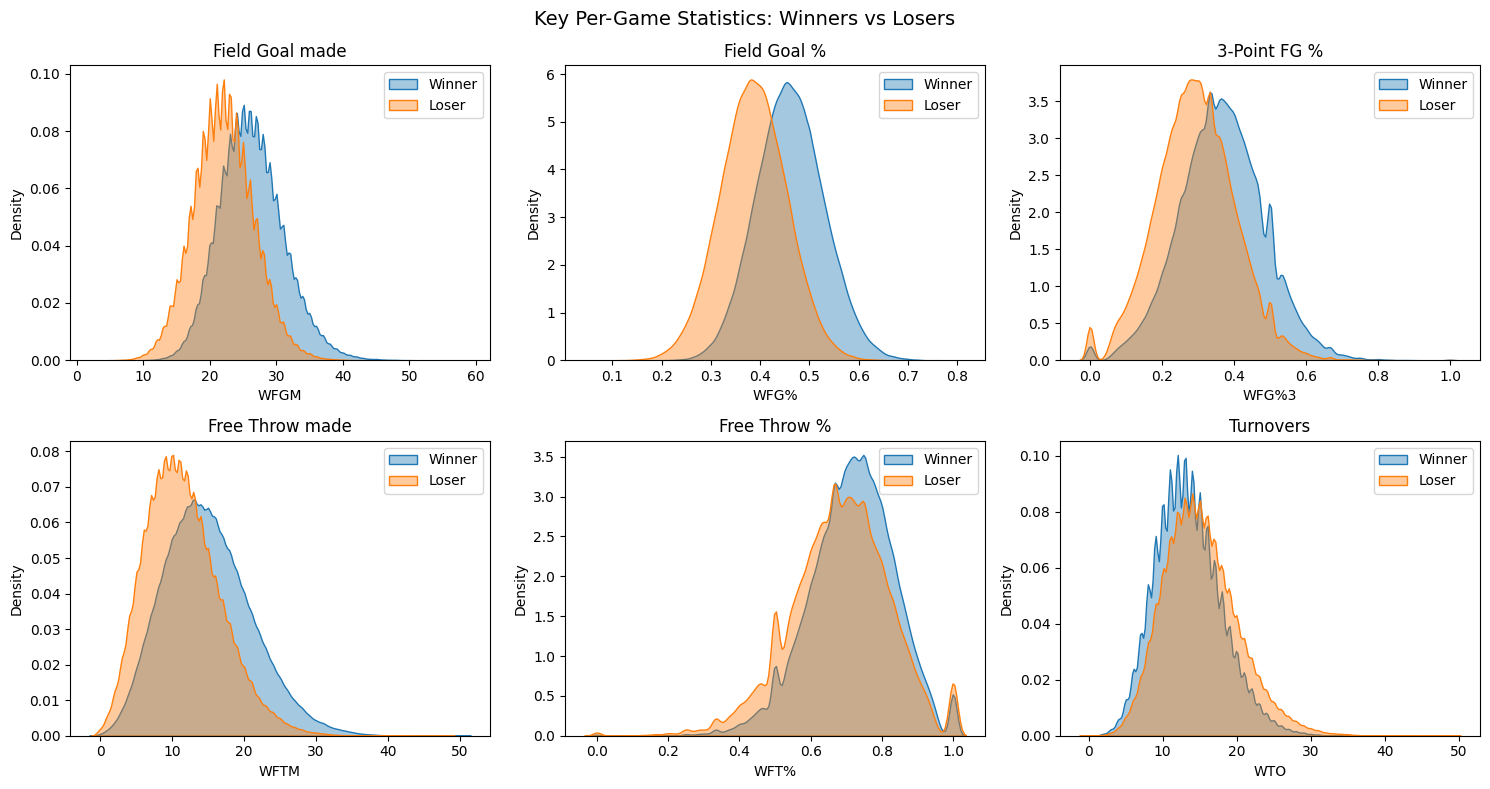

In [118]:
# comparing key per-game statistics for winners and losers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
stats_pairs = [
    ('WFGM',    'LFGM',    'Field Goal made'),
    ('WFG%',    'LFG%',    'Field Goal %'),
    ('WFG%3',   'LFG%3',   '3-Point FG %'),
    ('WFTM',    'LFTM',    'Free Throw made'),
    ('WFT%',    'LFT%',    'Free Throw %'),
    ('WTO',     'LTO',     'Turnovers'),
]
for ax, (w_col, l_col, title) in zip(axes.flat, stats_pairs):
    seaborn.kdeplot(rr[w_col].dropna(), label='Winner', ax=ax, fill=True, alpha=0.4)
    seaborn.kdeplot(rr[l_col].dropna(), label='Loser',  ax=ax, fill=True, alpha=0.4)
    ax.set_title(title)
    ax.legend()
plt.suptitle('Key Per-Game Statistics: Winners vs Losers', fontsize=14)
plt.tight_layout()
plt.show()

## Data preparation
Our current dataset is on the POV of winners: WTeam is always the winning team, and this might not be ideal for our predictions (which are inherently ordered). We want our model to be independent on the order of teams: we will process our dataset so to contain T1_stats and T2_stats, where T1 and T2 order do not determine the vicory.

We will duplicate our dataset, each match will appear twice, and each team will be one time T1 and one time T2.

Given the high number of matches with NumOT > 0, we will also apply an adjustment to take into account more stats collected:

$$\text{adjusted stat} = \text{raw stat} \times \frac{40}{40 + 5 \times \text{NumOT}}$$

`NB:` 40 corresponds to match duration, 5 correspond to over-time duration (in mins).

Our objective is to output a probability of victory for each match in the tournament, given the features built from the regular season results.


In [119]:
def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    """Transform winning-POV dataset into T1-T2 teams, where each match appears twice."""
    df = df.copy()
    columns_to_adjust = ['WScore', 'LScore', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
        'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
        'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
    adjust_coeff = 40 / (df["NumOT"] * 5 + 40)

    for c in columns_to_adjust:
        df[c] = df[c] * adjust_coeff
    
    df_2 = df.copy()

    df["Outcome"] = "win"
    df["ScoreDiff"] = df["WScore"] - df["LScore"]
    df_2["Outcome"] = "lose"
    df_2["ScoreDiff"] = df_2["LScore"] - df_2["WScore"]

    df.columns = [c.replace("W","T1").replace("L","T2") for c in df.columns]
    df["T1Loc"] = df["T1T2oc"] # The replace function didn't work for this :P
    df["T2Loc"] = df["T1Loc"].apply(lambda x: "A" if x =="H" else "H" if x == "A" else "N")
    df_2.columns = [c.replace("W","T2").replace("L","T1") for c in df_2.columns]
    df_2["T1Loc"] = df["T2Loc"]
    df_2["T2Loc"] = df["T1Loc"]
    df.drop(columns=["T1T2oc"], inplace=True)
    df_2.drop(columns=["T2T1oc"], inplace=True)
    final_df = pd.concat([df,df_2]).reset_index(drop=True)

    return final_df

In [120]:
regular_results = prepare_df(regular_results_df)
tourney_results = prepare_df(tourney_results_df)
seeds = seeds_df.copy() # just to be coherent with the naming

## Feature Engineering
### Easy features
First of all, let's build easy features that we already have. Let's introduce seed for each team, and compute their difference (which is more informative than the absolute seed itself).

Remember that we will use regular season's results to compute the features, and tourney results to train our model and make predictions!



In [121]:
seeds["int_seed"] = seeds_df["Seed"].map((lambda x: int(x[1:3])))
seeds.drop(columns=["Seed"], inplace=True)
seeds_T1 = seeds.copy().rename(columns={"TeamID": "T1TeamID", "int_seed": "T1Seed"}) # to ease the merge
seeds_T2 = seeds.copy().rename(columns={"TeamID": "T2TeamID", "int_seed": "T2Seed"}) # to ease the merge

Tournaments results might give us some insights on their correlation with regular season results. We didn't do this research and we will simply drop all the stats related to those games.   

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**
- instead of dropping those columns, do plots or compare those averages with regular season averages.
- whatever you can think of

In [122]:
tourney_columns = ['Season', 'T1TeamID', 'T2TeamID', 'Outcome', 'ScoreDiff', 'Category']
tourney_results = tourney_results[tourney_columns]
tourney_results = tourney_results.merge(seeds_T1, 
                                       on=["Season", "T1TeamID"], 
                                       how="left").merge(seeds_T2, 
                                                         on=["Season", "T2TeamID"], 
                                                         how="left")
tourney_results["SeedDiff"] = tourney_results["T1Seed"] - tourney_results["T2Seed"]

### Basketball-specific per-game features:
Now we build basketball-specific features for each game!  

*Efficiency metrics*:
- Offensive efficiency  —> Points scored per offensive possession. (Score / Possession) * 100 
- Defensive efficiency  —> Points allowed per defensive possession. (Score / Possession) * 100 
- Net Efficiency        —> OE - DE
- Possessions           —> Number of times a team controls the ball and completes a sequence. FGA - OR + TO + (0.44 * FTA)  

*Shooting Metrics*:
- **Effective FG%** (eFG%)  —> (FGM + 0.5 * FGM3) / FGA (weights 3-pointers correctly)
- True Shooting% (TS%)  —> Score / (2 * (FGA + 0.44 * FTA))
- **Free throw rate**       —> FTM / FTA
- Draw fouls ability    —> FTA / FGA
- General shooting rates—> Made / Attempted

*Reboundings*:
- **Offensive rebounds** %  —> OR / (OR + Opp_DR)
- Defensive Rebound %   —> DR / (DR + Opp_OR)
- Total Rebound margin  —> OR - DR

*Team style*:
- **Turnover rate**           —> TO / Possessions
- Steal-to-Turnover       —> Stl / TO
- Assist-to-Turnover      —> Ast / TO  


**Stats** in bolds are **the four factors**: they explains most of the matches according to experts.  

Additionally, given the home-court advantage, we will compute an adjusted score that compensate for this with the data-driven values we computed during data exploration.

In [123]:
# home advantage is computed as (home_score_mean - away_score_mean)/2

LOCATION_ADJUSTED = {"H": -home_advantage,
                     "A": home_advantage,
                     "N": 0.0}

In [124]:
def compute_possessions(fga, or_, to, fta):
    return fga - or_ + to + 0.44 * fta

def build_per_game_features(df):
    df = df.copy()

    # adjusting the score based on location (additional feature)
    for team in ["T1", "T2"]:
        adj_points = df[f"{team}Loc"].map(LOCATION_ADJUSTED)
        df[f"{team}Score_adj"] = df[f"{team}Score"] + adj_points
    
        # computing possessions
        df[f"{team}Poss"] = compute_possessions(
            df[f"{team}FGA"], df[f"{team}OR"], df[f"{team}TO"], df[f"{team}FTA"]
        )

        # offensive efficiency
        df[f"{team}OE"] = (df[f"{team}Score_adj"] / df[f"{team}Poss"]) * 100

        # shooting metrics
        df[f"{team}eFG"] = (df[f"{team}FGM"] + 0.5 * df[f"{team}FGM3"]) / df[f"{team}FGA"] # 1 of the Four Factors
        df[f"{team}TS"] = df[f"{team}Score"] / (2 * (df[f"{team}FGA"] + 0.44 * df[f"{team}FTA"])) 
        df[f"{team}FT%"] = df[f"{team}FTM"] / df[f"{team}FTA"]
        df[f"{team}FTRate"] = df[f"{team}FTA"] / df[f"{team}FGA"] # 1 of the Four Factors
        df[f"{team}FG%"] = df[f"{team}FGM"] / df[f"{team}FGA"]
        df[f"{team}FG%3"] = df[f"{team}FGM3"] / df[f"{team}FGA3"]

        # team style
        df[f'{team}TORate']  = df[f'{team}TO']  / df[f'{team}Poss'] # 1 of the Four Factors
        df[f'{team}StlTORate'] = df[f'{team}Stl'] / (df[f'{team}TO'] + 1e-6)
        df[f'{team}AstTORate'] = df[f'{team}Ast'] / (df[f'{team}TO'] + 1e-6)

    # defensive efficiency
    df["T1DE"] = (df["T2Score_adj"] / df["T2Poss"]) * 100
    df["T2DE"] = (df["T1Score_adj"] / df["T1Poss"]) * 100

    # net efficiency
    df["T1NE"] = df["T1OE"] - df["T1DE"]
    df["T2NE"] = df["T2OE"] - df["T2DE"]

    # reboundings
    df['T1ORRate'] = df['T1OR'] / (df['T1OR'] + df['T2DR']) # 1 of the Four Factors
    df['T1DRRate'] = df['T1DR'] / (df['T1DR'] + df['T2OR']) # 1 of the Four Factors
    df['T2ORRate'] = df['T2OR'] / (df['T2OR'] + df['T1DR'])
    df['T2DRRate'] = df['T2DR'] / (df['T2DR'] + df['T1OR'])

    return df

In [125]:
regular_results_per_game_stats = build_per_game_features(regular_results)

## Elo Rating

The **Elo rating** is a method for quantifying the relative skill of teams. Each team starts at 1500 (hyperparameter) and is updated after every game:

$$r_{\text{new}} = r_{\text{old}} + K \cdot \text{MoV} \cdot (o - e)$$

- $o \in \{0, 1\}$: actual outcome  
- $e$: expected win probability derived from the rating gap  
- $K = 32$: update speed (hyperparameter)
- **MoV** (Margin of Victory multiplier): $\log(|\Delta\text{score}| + 1)$ — rewards convincing wins  

At the start of each new season ratings are **regressed 40 % toward the mean** to account for roster changes. The end-of-season rating is carried into the tournament as a feature.

In [126]:
INITIAL_ELO = 1500
K = 32
HOME_ADVANTAGE_ELO = 100   # ELO points bonus for home team; a team playing home is stronger than expected.
SEASON_REGRESSION = 0.4
MEAN_ELO = 1500

In [127]:
def expected_score(r1, r2, t1_loc):
    adj = {'H': HOME_ADVANTAGE_ELO, 'A': -HOME_ADVANTAGE_ELO, 'N': 0}[t1_loc]
    return 1 / (1 + 10 ** (-(r1 - r2 + adj) / 400))
 
def mov_multiplier(point_diff, elo_diff):
    """mov multiplier according to fivethirthyeight"""
    mov = np.log(abs(point_diff) + 1)
    return mov

In [128]:
def compute_elo(df):
    """
    Compute pre-game ELO ratings for every game.
    Returns df with T1_Elo_Before, T2_Elo_Before columns.
    Also returns final ELO dict per (Season, TeamID) for use as tournament features.
    """
    df = df.sort_values(['Season', 'DayNum']).reset_index(drop=True).copy()
    elo = {}
    season_end_elo = {}   # {(season, team_id): elo}
 
    t1_elo_before, t2_elo_before = [], []
    current_season = None
 
    for _, row in df.iterrows():
        t1, t2 = int(row['T1TeamID']), int(row['T2TeamID'])
        season = row['Season']
 
        # season transition: save end-of-season ratings, then regress to mean
        if season != current_season:
            if current_season is not None:
                for tid, rating in elo.items():
                    season_end_elo[(current_season, tid)] = rating
                    elo[tid] = MEAN_ELO + (rating - MEAN_ELO) * (1 - SEASON_REGRESSION)
            current_season = season
 
        r1 = elo.get(t1, INITIAL_ELO)
        r2 = elo.get(t2, INITIAL_ELO)
 
        t1_elo_before.append(r1)
        t2_elo_before.append(r2)
 
        e1 = expected_score(r1, r2, row['T1Loc'])
        e2 = 1 - e1
 
        o1 = 1 if row['Outcome'] == 'win' else 0
        o2 = 1 - o1
 
        winner_elo_diff = (r1 - r2) if o1 == 1 else (r2 - r1)
        multiplier = mov_multiplier(row['ScoreDiff'], winner_elo_diff)
 
        elo[t1] = r1 + K * multiplier * (o1 - e1)
        elo[t2] = r2 + K * multiplier * (o2 - e2)
 
    # save last season: this will be used as feature
    for tid, rating in elo.items():
        season_end_elo[(current_season, tid)] = rating
 
    df['T1_Elo_Before'] = t1_elo_before
    df['T2_Elo_Before'] = t2_elo_before
 
    return df, season_end_elo

In [129]:
regular_results_per_game_stats_with_elo, season_end_elo = compute_elo(regular_results_per_game_stats)

### Aggregate features per season

We now aggregate all per-game statistics to obtain one row per *(Season, TeamID)*. This gives us the **average performance** of each team throughout the regular season against the average opponent, which is what we will use as input features for the tournament model (stats beginning with T1). Additionally, we will also have the average performance of an opponent against the team under analysis, which will be also used as input features (stats beginning with T2).

Two types of aggregated columns are produced:
- **Raw averages** — mean of each per-game stat (e.g. `T1_avg_Score`, `T1_avg_eFG`, `T1_Opponent_avg_Score`, `T1_Opponent_avg_eFG`)
- **Diff stats** — difference between T1 and T2 metrics within each game, then averaged (e.g. `T1_avg_NEDiff = mean(T1NE - T2NE)`)

In [130]:
DIFF_STATS = [ # stats for which we will compute differences
    'OE', 'DE', 'NE',
    'eFG', 'TS', 
    'ORRate', 'DRRate',
    'TORate', 'FTRate',
    'AstTORate', 'StlTORate', 
    'Score_adj'
]

AVG_STATS = [ # stats for which we will compute the average
    'T1Score', 'T2Score',
    'NumOT', 'T1FGM', 'T1FGA', 'T1FGM3', 'T1FGA3', 'T1FTM', 'T1FTA', 'T1OR',
    'T1DR', 'T1Ast', 'T1TO', 'T1Stl', 'T1Blk', 'T1PF', 'T2FGM', 'T2FGA',
    'T2FGM3', 'T2FGA3', 'T2FTM', 'T2FTA', 'T2OR', 'T2DR', 'T2Ast', 'T2TO',
    'T2Stl', 'T2Blk', 'T2PF', 'ScoreDiff', 'T1Score_adj', 'T1Poss', 'T1OE', 'T1eFG', 'T1TS', 'T1FT%',
    'T1FDA', 'T1FG%', 'T1FG%3', 'T1TORate', 'T1StlTORate', 'T1AstTORate',
    'T2Score_adj', 'T2Poss', 'T2OE', 'T2eFG', 'T2TS', 'T2FT%', 'T2FDA',
    'T2FG%', 'T2FG%3', 'T2TORate', 'T2StlTORate', 'T2AstTORate', 'T1DE',
    'T2DE', 'T1NE', 'T2NE', 'T1ORRate', 'T1DRRate', 'T2ORRate', 'T2DRRate']

def compute_diff_stats(df):
    """
    Compute per-game diff stats.
    """
    df = df.copy()
    for feature in DIFF_STATS:
        df[f"T1{feature}Diff"] = df[f"T1{feature}"] - df[f"T2{feature}"] # we compute the diff featuers in the POV of T1.

    return df

def aggregate_team_season(df):
    """
    Aggregate per-game stats to one row per (Season, TeamID).
    """
    columns_to_average = list(set(df.columns) - {'Category','DayNum','Outcome','Season','T1Loc','T1TeamID','T2Loc','T2TeamID'})
    df = df.copy().groupby(["Season", "T1TeamID"])[columns_to_average].mean().reset_index()
    return df
    
def create_features(results_df, tourney_df):
    df_T1 = results_df.copy()
    df_T2 = results_df.copy()
    features_df = tourney_df.copy()
    df_T1.columns = ["T1_avg_" + c.replace("T1","").replace("T2","Opponent_") for c in df_T1.columns]
    df_T1.rename(columns={"T1_avg_Season": "Season", "T1_avg_TeamID": "T1TeamID"}, inplace=True)
    df_T2.columns = ["T2_avg_" + c.replace("T1","").replace("T2","Opponent_") for c in df_T2.columns]
    df_T2.rename(columns={"T2_avg_Season": "Season", "T2_avg_TeamID": "T2TeamID"}, inplace=True)
    
    features_df = pd.merge(features_df, df_T1, on=["Season", "T1TeamID"], how="left")
    features_df = pd.merge(features_df, df_T2, on=["Season", "T2TeamID"], how="left")

    return features_df


In [131]:
tourney_results_with_features = create_features(
    aggregate_team_season(
        compute_diff_stats(regular_results_per_game_stats_with_elo)
        ), tourney_results)

In [132]:
tourney_results_with_features

,Season,T1TeamID,T2TeamID,Outcome,ScoreDiff,Category,T1Seed,T2Seed,SeedDiff,T1_avg_FGM3,T1_avg_Opponent_DE,T1_avg_Opponent_FT%,T1_avg_TORate,T1_avg_Opponent_TS,T1_avg_ORRateDiff,T1_avg_Opponent_FG%,T1_avg_Blk,T1_avg_FT%,T1_avg_Opponent_FTRate,T1_avg_FTRate,T1_avg_eFGDiff,T1_avg_DRRateDiff,T1_avg_StlTORateDiff,T1_avg_Opponent_Blk,T1_avg_Opponent__Elo_Before,T1_avg_Opponent_NE,T1_avg_DE,T1_avg_Score_adjDiff,T1_avg_FG%3,T1_avg_Opponent_DRRate,T1_avg_Opponent_TORate,T1_avg_Opponent_TO,T1_avg_Opponent_FTA,T1_avg_AstTORateDiff,T1_avg_Opponent_Ast,T1_avg_Score,T1_avg_Opponent_OR,T1_avg_NumOT,T1_avg_Score_adj,T1_avg_FG%,T1_avg_Opponent_Score,T1_avg_Opponent_DR,T1_avg_OR,T1_avg_Opponent_OE,T1_avg_AstTORate,T1_avg_FTM,T1_avg_Opponent_FTM,T1_avg_FGA3,T1_avg_Opponent_Stl,T1_avg_Opponent_Score_adj,T1_avg__Elo_Before,T1_avg_Ast,T1_avg_Opponent_FGM3,T1_avg_ScoreDiff,T1_avg_eFG,T1_avg_Opponent_eFG,T1_avg_FTA,T1_avg_Opponent_FGA,T1_avg_TORateDiff,T1_avg_TSDiff,T1_avg_FGA,T1_avg_OE,T1_avg_Opponent_Poss,T1_avg_Opponent_AstTORate,T1_avg_OEDiff,T1_avg_Poss,T1_avg_Opponent_FG%3,T1_avg_DEDiff,T1_avg_StlTORate,T1_avg_PF,T1_avg_FTRateDiff,T1_avg_ORRate,T1_avg_DR,T1_avg_Stl,T1_avg_NE,T1_avg_Opponent_FGM,T1_avg_Opponent_PF,T1_avg_FGM,T1_avg_NEDiff,T1_avg_TS,T1_avg_Opponent_FGA3,T1_avg_TO,T1_avg_DRRate,T1_avg_Opponent_ORRate,T1_avg_Opponent_StlTORate,T2_avg_FGM3,T2_avg_Opponent_DE,T2_avg_Opponent_FT%,T2_avg_TORate,T2_avg_Opponent_TS,T2_avg_ORRateDiff,T2_avg_Opponent_FG%,T2_avg_Blk,T2_avg_FT%,T2_avg_Opponent_FTRate,T2_avg_FTRate,T2_avg_eFGDiff,T2_avg_DRRateDiff,T2_avg_StlTORateDiff,T2_avg_Opponent_Blk,T2_avg_Opponent__Elo_Before,T2_avg_Opponent_NE,T2_avg_DE,T2_avg_Score_adjDiff,T2_avg_FG%3,T2_avg_Opponent_DRRate,T2_avg_Opponent_TORate,T2_avg_Opponent_TO,T2_avg_Opponent_FTA,T2_avg_AstTORateDiff,T2_avg_Opponent_Ast,T2_avg_Score,T2_avg_Opponent_OR,T2_avg_NumOT,T2_avg_Score_adj,T2_avg_FG%,T2_avg_Opponent_Score,T2_avg_Opponent_DR,T2_avg_OR,T2_avg_Opponent_OE,T2_avg_AstTORate,T2_avg_FTM,T2_avg_Opponent_FTM,T2_avg_FGA3,T2_avg_Opponent_Stl,T2_avg_Opponent_Score_adj,T2_avg__Elo_Before,T2_avg_Ast,T2_avg_Opponent_FGM3,T2_avg_ScoreDiff,T2_avg_eFG,T2_avg_Opponent_eFG,T2_avg_FTA,T2_avg_Opponent_FGA,T2_avg_TORateDiff,T2_avg_TSDiff,T2_avg_FGA,T2_avg_OE,T2_avg_Opponent_Poss,T2_avg_Opponent_AstTORate,T2_avg_OEDiff,T2_avg_Poss,T2_avg_Opponent_FG%3,T2_avg_DEDiff,T2_avg_StlTORate,T2_avg_PF,T2_avg_FTRateDiff,T2_avg_ORRate,T2_avg_DR,T2_avg_Stl,T2_avg_NE,T2_avg_Opponent_FGM,T2_avg_Opponent_PF,T2_avg_FGM,T2_avg_NEDiff,T2_avg_TS,T2_avg_Opponent_FGA3,T2_avg_TO,T2_avg_DRRate,T2_avg_Opponent_ORRate,T2_avg_Opponent_StlTORate
0,2003,1421,1411,win,7.111111,0,16,16,0,6.348659,102.473386,0.655791,0.230355,0.552615,-0.027197,0.454057,2.937165,0.766142,0.377704,0.377214,-0.026415,-0.027197,-0.257086,4.141762,1458.045968,9.397573,111.870959,-6.971267,0.363494,0.652816,0.183443,12.568582,22.157854,-0.464162,15.563218,69.615326,13.463602,0.172414,69.795976,0.432768,76.947893,22.401533,12.011494,111.870959,0.916938,15.571648,15.004598,17.658238,8.679693,76.767243,1363.080650,12.740230,7.459004,-7.332567,0.489800,0.516215,20.428352,59.712644,0.046912,-0.010790,55.639847,102.473386,68.567080,1.381099,-9.397573,68.547862,0.369765,9.397573,0.483437,18.769349,-0.000490,0.347184,22.652874,6.927969,-9.397573,27.242146,18.265134,23.847510,-18.795145,0.541825,20.307280,15.931034,0.625619,0.374381,0.740523,5.911111,104.279156,0.615019,0.218210,0.520145,0.041855,0.428747,2.222222,0.613745,0.318144,0.529491,0.011171,0.041855,-0.157282,2.596296,1337.275340,-4.197035,100.082121,1.773520,0.321414,0.639867,0.201657,14.259259,18.655556,-0.112064,13.718519,72.533333,11.881481,0.033333,72.446019,0.448892,70.585185,22.781481,13.103704,100.082121,0.983780,17.333333,11.914815,18.437037,7.977778,70.672499,1396.575755,14.140741,7.507407,1.948148,0.503036,0.491864,27.929630,60.140741,0.016553,0.019674,55.051852,104.279156,70.726963,1.095844,4.197035,69.403852,0.333551,-4.197035,0.454459,18.211111,0.211347,0.360133,24.6

For the Elo feature, we do not want to use the average throughout the season, but the Elo at the end of the season.  
Let's correct Elo values to the last of the regular season, and let's compute the diff and the elo_win_probability as features!

In [133]:
tourney_results_with_features["T1_Elo"] = tourney_results_with_features.apply(
        lambda r: season_end_elo.get((r['Season'], int(r['T1TeamID'])), INITIAL_ELO), axis=1
    )

tourney_results_with_features["T2_Elo"] = tourney_results_with_features.apply(
        lambda r: season_end_elo.get((r['Season'], int(r['T2TeamID'])), INITIAL_ELO), axis=1
    )

tourney_results_with_features["EloDiff"] = tourney_results_with_features["T1_Elo"] - tourney_results_with_features["T2_Elo"]
tourney_results_with_features['elo_win_prob'] = 1 / (1 + 10 ** (-tourney_results_with_features['EloDiff'] / 400))

tourney_results_with_features.drop(columns=[
    'T1_avg__Elo_Before',
    'T1_avg_Opponent__Elo_Before',
    'T2_avg__Elo_Before',
    'T2_avg_Opponent__Elo_Before',],
    inplace=True) # we do not need those features!

### LateSeasonRank regression for Women
We have ordinal rankings for Men competition only. We will try to do regression on this feature for Men and compute it for Women.  

Let's extract the mean of the last 5 games and use it as a feature explaining the late season ranking (a team might get better/worse throughout a season!)

In [134]:
grouped_ordinals = M_massey_ordinals_df.groupby(["Season","TeamID","RankingDayNum"])["OrdinalRank"].mean().reset_index()

M_ordinals = pd.DataFrame(columns=["Season","TeamID","LateSeasonRank"])
seasons, team_ids, late_season_ranks = [],[],[]
for season in grouped_ordinals["Season"].unique():
    for team_id in grouped_ordinals[grouped_ordinals["Season"]==season]["TeamID"].unique():
        seasons.append(season)
        team_ids.append(team_id)
        late_season_ranks.append(
            grouped_ordinals[(grouped_ordinals["Season"]==season) & (grouped_ordinals["TeamID"]==team_id)]["OrdinalRank"][-5:].mean()
        )

M_ordinals["Season"] = seasons
M_ordinals["TeamID"] = team_ids
M_ordinals["LateSeasonRank"] = late_season_ranks

M_ordinals

,Season,TeamID,LateSeasonRank
0,2003,1102,158.939583
1,2003,1103,166.284848
2,2003,1104,34.591098
3,2003,1105,306.896780
4,2003,1106,247.079924
...,...,...,...
8351,2026,1477,297.716755
8352,2026,1478,297.588690
8353,2026,1479,289.077499
8354,2026,1480,291.901605


Let's select some features for regressing LateSeasonRank (Four Factors!)

In [135]:
features_for_regression = [
'T1Seed',
'T1_avg_Score',
# 'T1_avg_Blk',
# 'T1_avg_AstTORate',
'T1_avg_FTRate',
# 'T1_avg_FTM',
# 'T1_avg_Stl',
# 'T1_avg_FG%3',
'T1_avg_eFG',
# 'T1_avg_FGM3',
'T1_avg_DRRate',
# 'T1_avg_Score_adj',
'T1_avg_NE',
# 'T1_avg_NumOT',
# 'T1_avg_Ast',
# 'T1_avg_OR',
# 'T1_avg_OE',
# 'T1_avg_FGA3',
# 'T1_avg_Poss',
# 'T1_avg_PF',
# 'T1_avg_FTA',
# 'T1_avg_FT%',
# 'T1_avg_FGA',
# 'T1_avg_TS',
# 'T1_avg_StlTORate',
'T1_avg_TORate',
# 'T1_avg_DE',
# 'T1_avg_FG%',
# 'T1_avg_FGM',
'T1_avg_ORRate',
'T1_Elo']

In [136]:
tourney_results_with_regression_features = tourney_results_with_features[['Season','T1TeamID'] + features_for_regression]

In [137]:
# tourney_results_with_regression_features has one row per match per team.
# since we only kept T1 features, matches for the same team are duplicates. we will drop them.

M_tourney_results_with_regression_features = tourney_results_with_regression_features.loc[tourney_results_with_features["Category"]==0].drop_duplicates()
W_tourney_results_with_regression_features = tourney_results_with_regression_features.loc[tourney_results_with_features["Category"]==1].drop_duplicates()
M_tourney_results_with_regression_features = M_tourney_results_with_regression_features.merge(M_ordinals.rename(columns={"TeamID": "T1TeamID", "LateSeasonRank": "T1LateSeasonRank"}), 
                                       on=["Season", "T1TeamID"], 
                                       how="left")


### Model for regression
We use a simple Ridge regression since it tends to work quite good.

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**
- try other models, looking at the scores.mean() produced. the lower, the better! additionally, look at the feature distribution below. the closer men's and women's distribution are, the better it is. To be honest, i am already satisfied with this model but if you have any idea just try. BE CAREFUL WITH OVERFITTING! EXTRA COMPLEX MODELS/FEATURES ARE NOT NEEDED (OCCAM'S RAZOR) 

In [138]:
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

regression_target = "T1LateSeasonRank"

X_train = M_tourney_results_with_regression_features.copy().drop(columns=regression_target)
y_train = M_tourney_results_with_regression_features[regression_target]


models = [
    Ridge(alpha=1.0),
    # other models?
]


# Fit and predict
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', models[0]),
])

model_log = TransformedTargetRegressor(regressor=model, func=np.log, inverse_func=np.exp)

model_log.fit(X_train, y_train) # for skewed distributions, log models tends to work better!

X_pred = W_tourney_results_with_regression_features.copy().drop_duplicates()
y_pred = model_log.predict(X_pred).clip(min=min(y_train), max=max(y_train))

scores = cross_val_score(model_log, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(scores.mean())

-15.511105891271603


The skewed distribution of Women Late Season Rank is very similar to the Men's one. Nice!

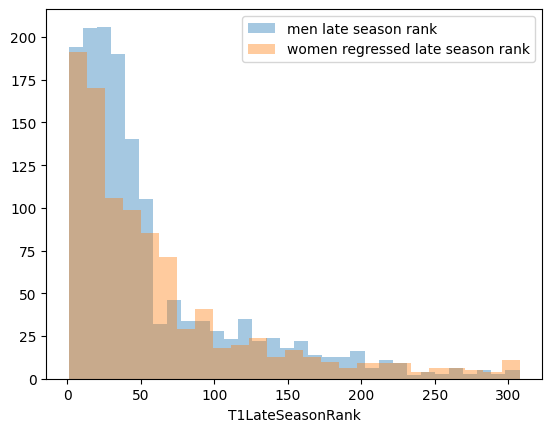

In [139]:
seaborn.distplot(y_train, label="men late season rank", kde=False)
seaborn.distplot(y_pred, label="women regressed late season rank", kde=False)
plt.legend()
plt.show()

Let's add the predicted late season rank

In [140]:
W_tourney_results_with_regression_features[regression_target] = y_pred

In [141]:
ordinals_regression_features = pd.concat([
    M_tourney_results_with_regression_features,
    W_tourney_results_with_regression_features
    ])[["Season","T1TeamID","T1LateSeasonRank"]]

ordinals_regression_features_T1 = ordinals_regression_features.copy()
ordinals_regression_features_T2 = ordinals_regression_features.copy()
ordinals_regression_features_T2.columns = [col.replace("T1", "T2") for col in ordinals_regression_features_T1.columns]

tourney_results_with_features = tourney_results_with_features.merge(ordinals_regression_features_T1,  
                                    on=["Season", "T1TeamID"], how="left").merge(ordinals_regression_features_T2,  
                                    on=["Season", "T2TeamID"], how="left")

tourney_results_with_features["LateSeasonRankDiff"] = tourney_results_with_features["T1LateSeasonRank"] - tourney_results_with_features["T2LateSeasonRank"]

### Features selection:
We build several features to use for predicting the outcomes. Which one are the best?

In [142]:
all_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
'T1_avg_FT%',
'T1_avg_TORate',
'T1_avg_Opponent_ORRate',
'T1_avg_FGA3',
'T1_avg_Opponent_FGM3',
'T1_avg_Opponent_Score',
'T1_avg_Opponent_Blk',
'T1_avg_FTM',
'T1_avg_ORRate',
'T1_avg_Opponent_Poss',
'T1_avg_FTRate',
'T1_avg_PF',
'T1_avg_eFGDiff',
'T1_avg_Opponent_NE',
'T1_avg_Poss',
'T1_avg_Opponent_TO',
'T1_avg_Opponent_DE',
'T1_avg_Opponent_FTM',
'T1_avg_Opponent_StlTORate',
'T1_avg_Opponent_DRRate',
'T1_avg_eFG',
'T1_avg_Opponent_OR',
'T1_avg_TSDiff',
'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
'T1_avg_Opponent_eFG',
'T1_avg_Opponent_FTRate',
'T1_avg_FGA',
'T1_avg_Opponent_FG%',
'T1_avg_FGM',
'T1_avg_FGM3',
'T1_avg_TORateDiff',
'T1_avg_Opponent_DR',
'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
'T1_avg_Opponent_FTA',
'T1_avg_TO',
'T1_avg_Opponent_Ast',
'T1_avg_StlTORate',
'T1_avg_OE',
'T1_avg_FG%3',
'T1_avg_AstTORate',
'T1_avg_AstTORateDiff',
'T1_avg_Score_adj',
'T1_avg_FTA',
'T1_avg_Opponent_TORate',
'T1_avg_Stl',
'T1_avg_Opponent_Stl',
'T1_avg_Opponent_FG%3',
'T1_avg_DR',
'T1_avg_ORRateDiff',
'T1_avg_Score',
'T1_avg_Opponent_FGA',
'T1_avg_Opponent_FT%',
'T1_avg_Score_adjDiff',
'T1_avg_OR',
'T1_avg_Opponent_AstTORate',
'T1_avg_OEDiff',
'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
'T1_avg_NE',
'T1_avg_StlTORateDiff',
'T1_avg_Opponent_TS',
'T1_avg_FG%',
'T1_avg_Opponent_Score_adj',
'T1_avg_DRRate',
'T1_avg_Blk',
'T1_avg_Opponent_PF',
'T1_avg_Opponent_FGA3',
'T1_avg_FTRateDiff',
'T1_avg_DEDiff',
'T1_avg_Ast',
'T1_avg_DE',
'T1_avg_TS',
'T2_avg_FT%',
'T2_avg_TORate',
'T2_avg_Opponent_ORRate',
'T2_avg_FGA3',
'T2_avg_Opponent_FGM3',
'T2_avg_Opponent_Score',
'T2_avg_Opponent_Blk',
'T2_avg_FTM',
'T2_avg_ORRate',
'T2_avg_Opponent_Poss',
'T2_avg_FTRate',
'T2_avg_PF',
'T2_avg_eFGDiff',
'T2_avg_Opponent_NE',
'T2_avg_Poss',
'T2_avg_Opponent_TO',
'T2_avg_Opponent_DE',
'T2_avg_Opponent_FTM',
'T2_avg_Opponent_StlTORate',
'T2_avg_Opponent_DRRate',
'T2_avg_eFG',
'T2_avg_Opponent_OR',
'T2_avg_TSDiff',
'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
'T2_avg_Opponent_eFG',
'T2_avg_Opponent_FTRate',
'T2_avg_FGA',
'T2_avg_Opponent_FG%',
'T2_avg_FGM',
'T2_avg_FGM3',
'T2_avg_TORateDiff',
'T2_avg_Opponent_DR',
'T2_avg_Opponent_FGM',
'T2_avg_NEDiff',
'T2_avg_Opponent_FTA',
'T2_avg_TO',
'T2_avg_Opponent_Ast',
'T2_avg_StlTORate',
'T2_avg_OE',
'T2_avg_FG%3',
'T2_avg_AstTORate',
'T2_avg_AstTORateDiff',
'T2_avg_Score_adj',
'T2_avg_FTA',
'T2_avg_Opponent_TORate',
'T2_avg_Stl',
'T2_avg_Opponent_Stl',
'T2_avg_Opponent_FG%3',
'T2_avg_DR',
'T2_avg_ORRateDiff',
'T2_avg_Score',
'T2_avg_Opponent_FGA',
'T2_avg_Opponent_FT%',
'T2_avg_Score_adjDiff',
'T2_avg_OR',
'T2_avg_Opponent_AstTORate',
'T2_avg_OEDiff',
'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
'T2_avg_NE',
'T2_avg_StlTORateDiff',
'T2_avg_Opponent_TS',
'T2_avg_FG%',
'T2_avg_Opponent_Score_adj',
'T2_avg_DRRate',
'T2_avg_Blk',
'T2_avg_Opponent_PF',
'T2_avg_Opponent_FGA3',
'T2_avg_FTRateDiff',
'T2_avg_DEDiff',
'T2_avg_Ast',
'T2_avg_DE',
'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob']

pred = "ScoreDiff"

In [143]:
only_diff_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
# 'T1Seed',
# 'T2Seed',
'SeedDiff',
# 'T1LateSeasonRank',
# 'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
# 'T1_avg_FGA3',
# 'T1_avg_Opponent_FGM3',
# 'T1_avg_Opponent_Score',
# 'T1_avg_Opponent_Blk',
# 'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
# 'T1_avg_PF',
# 'T1_avg__Elo_Before',
'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
# 'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
# 'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
# 'T1_avg_Opponent_OR',
'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
# 'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
# 'T1_avg_FGM',
# 'T1_avg_FGM3',
'T1_avg_TORateDiff',
# 'T1_avg_Opponent_DR',
# 'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
# 'T1_avg_Opponent_FTA',
# 'T1_avg_TO',
# 'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
# 'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
# 'T1_avg_Stl',
# 'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
# 'T1_avg_DR',
'T1_avg_ORRateDiff',
# 'T1_avg_Score',
# 'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
'T1_avg_Score_adjDiff',
# 'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
'T1_avg_OEDiff',
'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
# 'T1_avg_NE',
'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
# 'T1_avg_Blk',
# 'T1_avg_Opponent_PF',
# 'T1_avg_Opponent_FGA3',
'T1_avg_FTRateDiff',
'T1_avg_DEDiff',
# 'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
# 'T2_avg_FGA3',
# 'T2_avg_Opponent_FGM3',
# 'T2_avg_Opponent_Score',
# 'T2_avg_Opponent_Blk',
# 'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
# 'T2_avg_PF',
# 'T2_avg__Elo_Before',
'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
# 'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
# 'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
# 'T2_avg_Opponent_OR',
'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
# 'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
# 'T2_avg_FGM',
# 'T2_avg_FGM3',
'T2_avg_TORateDiff',
# 'T2_avg_Opponent_DR',
# 'T2_avg_Opponent_FGM',
'T2_avg_NEDiff',
# 'T2_avg_Opponent_FTA',
# 'T2_avg_TO',
# 'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
# 'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
# 'T2_avg_Stl',
# 'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
# 'T2_avg_DR',
'T2_avg_ORRateDiff',
# 'T2_avg_Score',
# 'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
'T2_avg_Score_adjDiff',
# 'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
'T2_avg_OEDiff',
'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
# 'T2_avg_NE',
'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
# 'T2_avg_Blk',
# 'T2_avg_Opponent_PF',
# 'T2_avg_Opponent_FGA3',
'T2_avg_FTRateDiff',
'T2_avg_DEDiff',
# 'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
# 'T1_Elo',
# 'T2_Elo',
'EloDiff',
# 'elo_win_prob'
]

In [144]:
minimal_raw_boxscore_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
'T1_avg_FGA3',
'T1_avg_Opponent_FGM3',
'T1_avg_Opponent_Score',
'T1_avg_Opponent_Blk',
'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
'T1_avg_PF',
# 'T1_avg__Elo_Before',
# 'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
'T1_avg_Opponent_OR',
# 'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
'T1_avg_FGM',
'T1_avg_FGM3',
# 'T1_avg_TORateDiff',
'T1_avg_Opponent_DR',
'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
'T1_avg_Opponent_FTA',
'T1_avg_TO',
'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
# 'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
'T1_avg_Stl',
'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
'T1_avg_DR',
# 'T1_avg_ORRateDiff',
'T1_avg_Score',
'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
# 'T1_avg_Score_adjDiff',
'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
# 'T1_avg_OEDiff',
# 'T1_avg_DRRateDiff',
# 'T1_avg_ScoreDiff',
# 'T1_avg_NE',
# 'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
'T1_avg_Blk',
'T1_avg_Opponent_PF',
'T1_avg_Opponent_FGA3',
# 'T1_avg_FTRateDiff',
# 'T1_avg_DEDiff',
'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
'T2_avg_FGA3',
'T2_avg_Opponent_FGM3',
'T2_avg_Opponent_Score',
'T2_avg_Opponent_Blk',
'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
'T2_avg_PF',
# 'T2_avg__Elo_Before',
# 'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
'T2_avg_Opponent_OR',
# 'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
'T2_avg_FGM',
'T2_avg_FGM3',
# 'T2_avg_TORateDiff',
'T2_avg_Opponent_DR',
'T2_avg_Opponent_FGM',
# 'T2_avg_NEDiff',
'T2_avg_Opponent_FTA',
'T2_avg_TO',
'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
# 'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
'T2_avg_Stl',
'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
'T2_avg_DR',
# 'T2_avg_ORRateDiff',
'T2_avg_Score',
'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
# 'T2_avg_Score_adjDiff',
'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
# 'T2_avg_OEDiff',
# 'T2_avg_DRRateDiff',
# 'T2_avg_ScoreDiff',
# 'T2_avg_NE',
# 'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
'T2_avg_Blk',
'T2_avg_Opponent_PF',
'T2_avg_Opponent_FGA3',
# 'T2_avg_FTRateDiff',
# 'T2_avg_DEDiff',
'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob']

pred = "ScoreDiff"

In [145]:
minimal_raw_features =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
# 'T1_avg_FGA3',
# 'T1_avg_Opponent_FGM3',
# 'T1_avg_Opponent_Score',
# 'T1_avg_Opponent_Blk',
# 'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
# 'T1_avg_PF',
# 'T1_avg__Elo_Before',
# 'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
# 'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
# 'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
# 'T1_avg_Opponent_OR',
# 'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
# 'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
# 'T1_avg_FGM',
# 'T1_avg_FGM3',
# 'T1_avg_TORateDiff',
# 'T1_avg_Opponent_DR',
# 'T1_avg_Opponent_FGM',
# 'T1_avg_NEDiff',
# 'T1_avg_Opponent_FTA',
# 'T1_avg_TO',
# 'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
# 'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
# 'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
# 'T1_avg_Stl',
# 'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
# 'T1_avg_DR',
# 'T1_avg_ORRateDiff',
'T1_avg_Score',
# 'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
# 'T1_avg_Score_adjDiff',
# 'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
# 'T1_avg_OEDiff',
# 'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
# 'T1_avg_NE',
# 'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
# 'T1_avg_Blk',
# 'T1_avg_Opponent_PF',
# 'T1_avg_Opponent_FGA3',
# 'T1_avg_FTRateDiff',
# 'T1_avg_DEDiff',
# 'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
# 'T2_avg_FGA3',
# 'T2_avg_Opponent_FGM3',
# 'T2_avg_Opponent_Score',
# 'T2_avg_Opponent_Blk',
# 'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
# 'T2_avg_PF',
# 'T2_avg__Elo_Before',
# 'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
# 'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
# 'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
# 'T2_avg_Opponent_OR',
# 'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
# 'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
# 'T2_avg_FGM',
# 'T2_avg_FGM3',
# 'T2_avg_TORateDiff',
# 'T2_avg_Opponent_DR',
# 'T2_avg_Opponent_FGM',
# 'T2_avg_NEDiff',
# 'T2_avg_Opponent_FTA',
# 'T2_avg_TO',
# 'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
# 'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
# 'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
# 'T2_avg_Stl',
# 'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
# 'T2_avg_DR',
# 'T2_avg_ORRateDiff',
'T2_avg_Score',
# 'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
# 'T2_avg_Score_adjDiff',
# 'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
# 'T2_avg_OEDiff',
# 'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
# 'T2_avg_NE',
# 'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
# 'T2_avg_Blk',
# 'T2_avg_Opponent_PF',
# 'T2_avg_Opponent_FGA3',
# 'T2_avg_FTRateDiff',
# 'T2_avg_DEDiff',
# 'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob'
]

pred = "ScoreDiff"

### Feature Distributions

Before training, let's inspect how the key features separate wins from losses in the tournament dataset.  

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**  
- Plot features (raw vs difference) to see which ones are the best to use!
- Some features are symmetric (with respect to the outcome): this is because of the duplication of our dataset, in which each match appears twice, one with T1 winner and one with T1 loser! we need another way to show those features in a meaningful way i guess! 

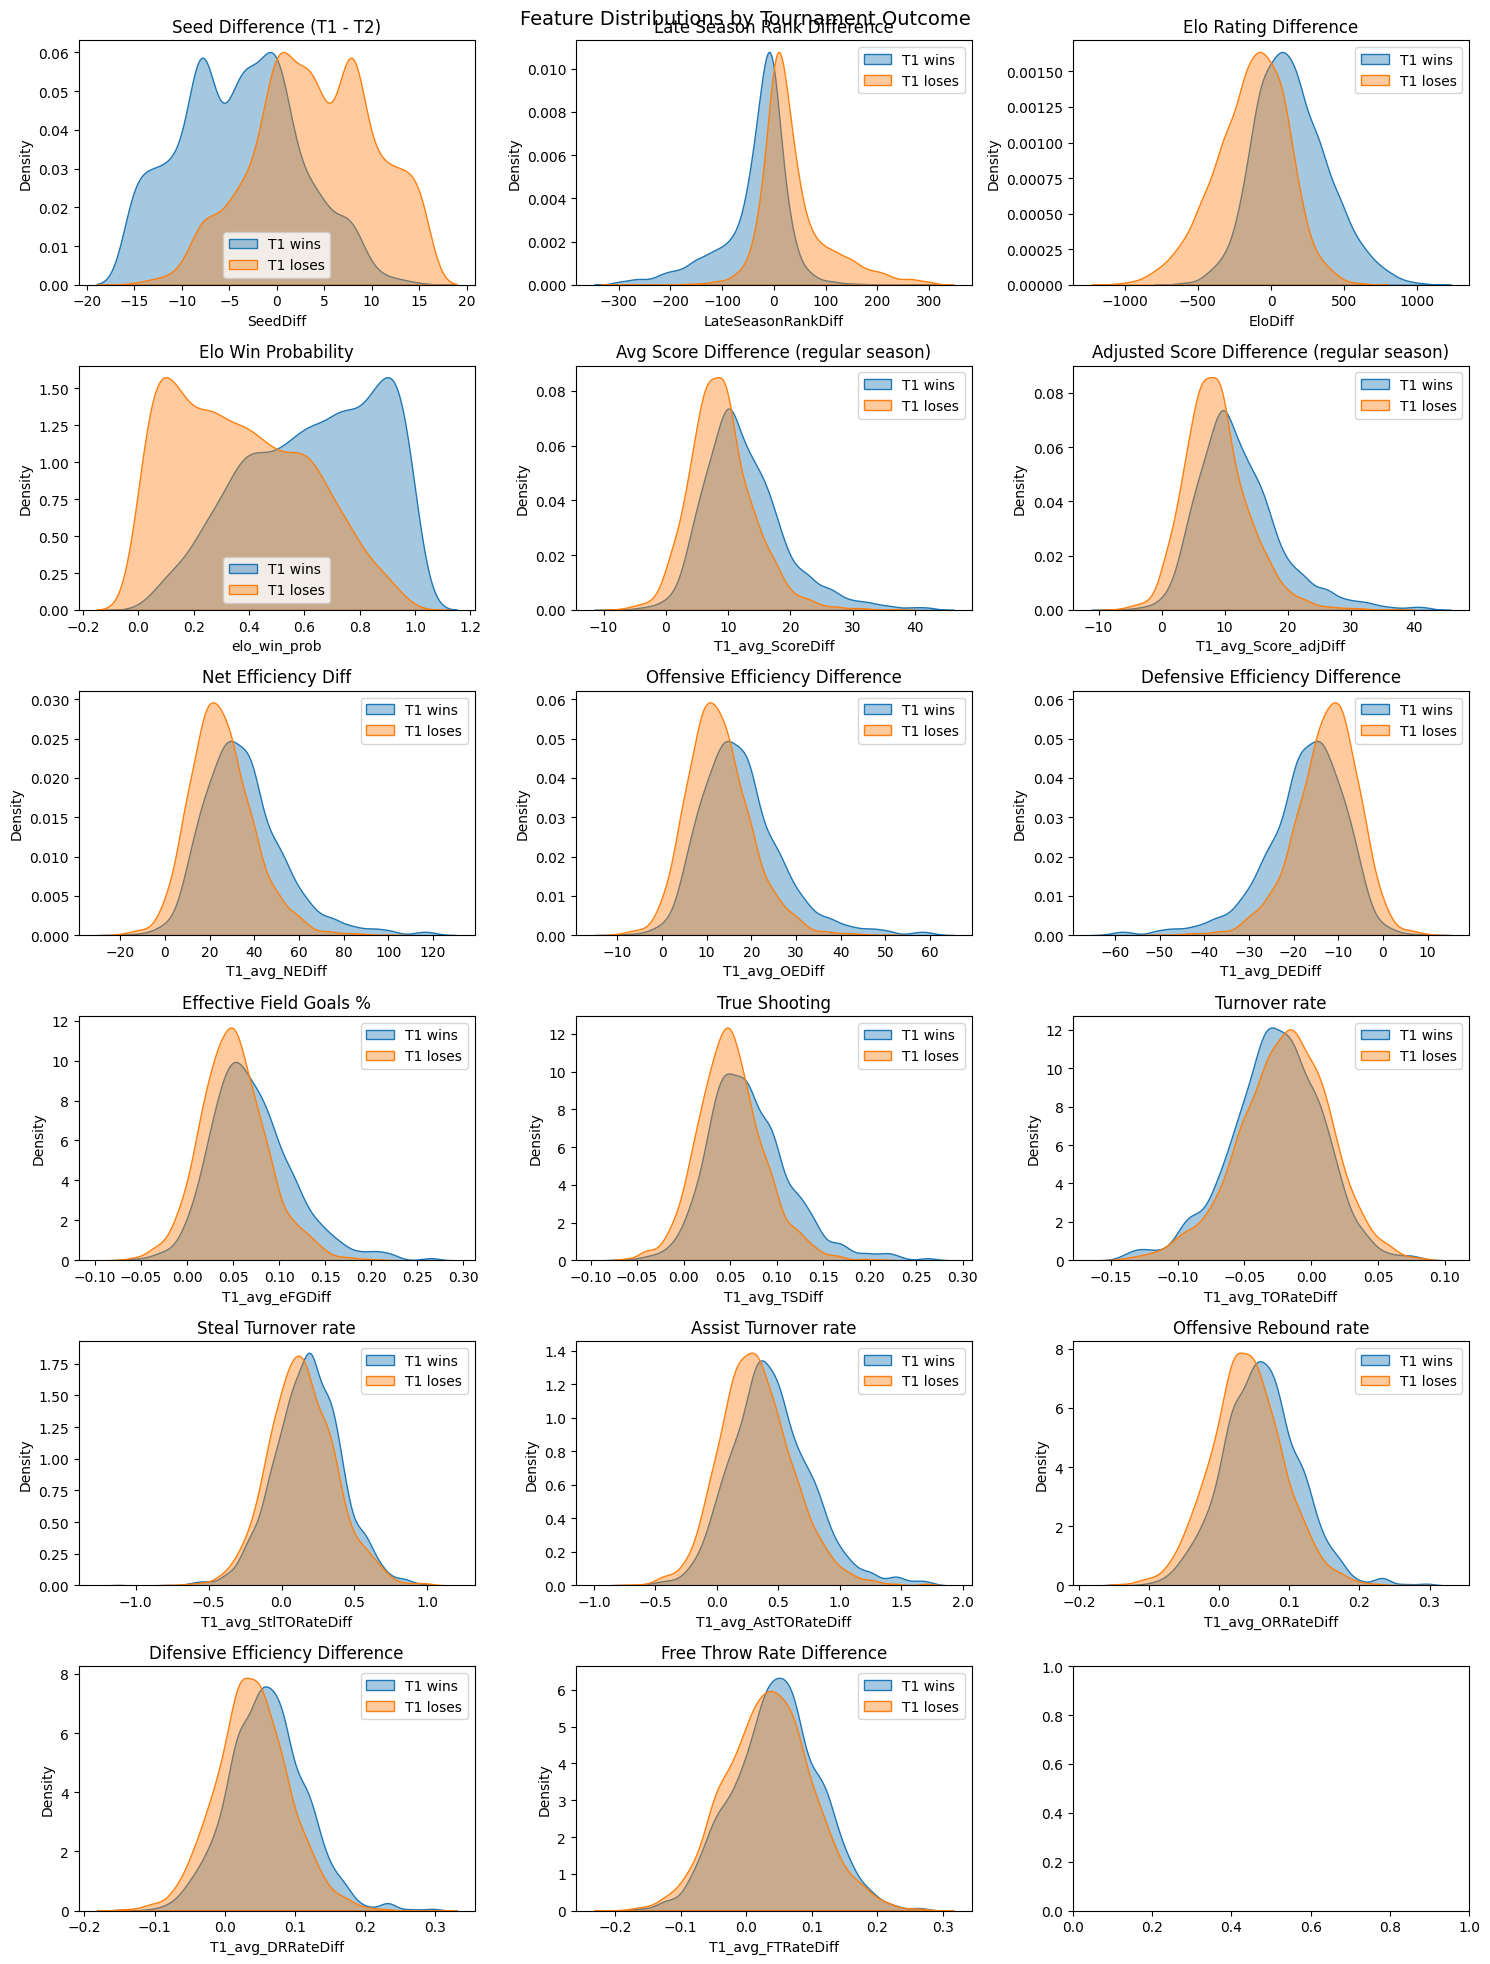

In [146]:
# Distribution of key engineered features, split by tournament outcome
features_to_plot = {
    'SeedDiff':          'Seed Difference (T1 - T2)',
    'LateSeasonRankDiff':'Late Season Rank Difference',
    'EloDiff':           'Elo Rating Difference',
    'elo_win_prob':      'Elo Win Probability',
    'T1_avg_ScoreDiff':  'Avg Score Difference (regular season)',
    'T1_avg_Score_adjDiff':  'Adjusted Score Difference (regular season)',
    'T1_avg_NEDiff':     'Net Efficiency Diff',
    'T1_avg_OEDiff':     'Offensive Efficiency Difference',
    'T1_avg_DEDiff':     'Defensive Efficiency Difference',
    'T1_avg_eFGDiff':    'Effective Field Goals %',
    'T1_avg_TSDiff':     'True Shooting',
    'T1_avg_TORateDiff': 'Turnover rate',
    'T1_avg_StlTORateDiff':      'Steal Turnover rate',
    'T1_avg_AstTORateDiff': 'Assist Turnover rate',
    'T1_avg_ORRateDiff':     'Offensive Rebound rate',
    'T1_avg_DRRateDiff':     'Difensive Efficiency Difference',
    'T1_avg_FTRateDiff':     'Free Throw Rate Difference',
}

wins   = tourney_results_with_features[tourney_results_with_features['Outcome'] == "win"]
losses = tourney_results_with_features[tourney_results_with_features['Outcome'] == "lose"]

fig, axes = plt.subplots(6, 3, figsize=(15, 20))
for ax, (col, title) in zip(axes.flat, features_to_plot.items()):
    seaborn.kdeplot(wins[col].dropna(),   label='T1 wins',  ax=ax, fill=True, alpha=0.4)
    seaborn.kdeplot(losses[col].dropna(), label='T1 loses', ax=ax, fill=True, alpha=0.4)
    ax.set_title(title)
    ax.legend()
plt.suptitle('Feature Distributions by Tournament Outcome', fontsize=14)
plt.tight_layout()
plt.show()

## Predicting the outcomes!
To predict the outcomes, we can either do it by classifying the match (win/lose) or by predicting the score difference, thus deriving the probability of the outcome depending on the magnitude of the difference. We will try both methods, using XGBOOST model.

As a cross-validation method, we will use one-season-out method: we keep one season out and train on all the others, keeping separate models for each cv-fold and optimize the hyperparameters on those out-of-fold seasons.  

Hyperparameter optimization is done with **optuna**, a smart library for hp optimization.

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**
- try a different model (i heard simple logistic regression might work well, but for this you need to transform the features into values between 0 and 1 and standardize them with mean 0 and variance 1.)
- during conversion from score_diff to probability of winning in `fit_predict_score_to_prob()`, we clip the output probability to 0.01,0.99. investigate whether we should clip or not and to which values



### 1. Regression on ScoreDiff
To predict the probability of winning of a team against the other, we will first do regression on the score difference between the 2 teams.  

We will always consider the POV of the first team (T1).

In [147]:
# we map "win", "lose" to 1, 0
tourney_results_with_features["Outcome"] = tourney_results_with_features["Outcome"].map(lambda x: 0 if x in ["lose", 0] else 1)

In [148]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# CONFIG

FEATURE_COLS = minimal_raw_features

TARGET_COL      = 'ScoreDiff'
TARGET_SEASON   = 2025
SEASONS         = sorted(tourney_results_with_features['Season'].unique())
SEASONS.remove(TARGET_SEASON)

OPTUNA_TRIALS = 50 

# cross-validation with one-season-out

def one_season_out_cv_regressor(df, feature_cols, target_col, params, verbose=False):

    oof_preds   = np.zeros(len(df))
    fold_scores = []

    for season in SEASONS:
        train = df[df['Season'] != season]
        val   = df[df['Season'] == season]

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_val   = val[feature_cols].values
        y_val   = val[target_col].values

        model = xgb.XGBRegressor(
            **params,
            eval_metric='rmse',
            random_state=42,
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        oof_preds[val.index] = preds

        fold_scores.append({
            'season': season,
            'mae':  mean_absolute_error(y_val, preds),
            'rmse': np.sqrt(mean_squared_error(y_val, preds)),
        })

        if verbose:
            s = fold_scores[-1]
            print(f"Season {season} — MAE: {s['mae']:.2f}  RMSE: {s['rmse']:.2f}")

    scores_df = pd.DataFrame(fold_scores)
    if verbose:
        print(f"\nMean MAE  : {scores_df['mae'].mean():.2f} ± {scores_df['mae'].std():.2f}")
        print(f"Mean RMSE : {scores_df['rmse'].mean():.2f} ± {scores_df['rmse'].std():.2f}")

    return scores_df, oof_preds

# fit ScoreDiff and probability conversion on OOF predictions

def fit_predict_score_to_prob(oof_score_diffs, actual_outcomes):
    """
    Fit a univariate spline.
    Using OOF predictions ensures no leakage.
    """
    max_score_difference = 25 # we clip the score difference predictions to 25 to avoid over-confidence
    dat = list(zip(oof_score_diffs, np.array(actual_outcomes)>0))
    dat = sorted(dat, key = lambda x: x[0])
    pred, label = list(zip(*dat))
    spline_model = UnivariateSpline(np.clip(pred, -max_score_difference, max_score_difference), label, k=5)
    oof_probs = np.clip(spline_model
                        (np.clip(oof_score_diffs, -max_score_difference, max_score_difference)
                         ), 
                         0.01, 0.99) # those values clip the output probability. should we clip or not? and to which values?

    return oof_probs


# optuna objective (minimizes RMSE + variance to reduce both)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
    }

    scores_df, _ = one_season_out_cv_regressor(
        tourney_results_with_features,
        FEATURE_COLS,
        TARGET_COL,
        params,
    )

    mean_rmse = scores_df['rmse'].mean()
    std_rmse  = scores_df['rmse'].std()
    return mean_rmse + 0.5 * std_rmse

# Full pipeline

# optimize
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
best_params = study.best_params

# final CV with best params to get OOF predictions
print(f"\n---------- TRAIN STATS -------------")

scores_df, oof_score_diffs = one_season_out_cv_regressor(
    tourney_results_with_features, FEATURE_COLS, TARGET_COL, best_params, verbose=True
)

# transform score_diffs in probabilities by fitting a univariate spline
actual_outcomes = tourney_results_with_features['Outcome'].values  # 1/0
oof_probs = fit_predict_score_to_prob(oof_score_diffs, actual_outcomes)

print(f"\nOOF log-loss : {log_loss(actual_outcomes, oof_probs):.4f}")
print(f"OOF Brier    : {brier_score_loss(actual_outcomes, oof_probs):.4f}")

# train final model on TARGET_SEASON
X_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][FEATURE_COLS].values
y_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][TARGET_COL].values
X_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][FEATURE_COLS].values
y_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][TARGET_COL].values
actual_outcomes = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON]['Outcome'].values  # 1/0

final_model = xgb.XGBRegressor(**best_params, random_state=42)
final_model.fit(X_train, y_train)

y_pred  = final_model.predict(X_test)
mae     = mean_absolute_error(y_test, y_pred)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))

probs = fit_predict_score_to_prob(y_pred, actual_outcomes)

print(f"\n---------- TEST STATS -------------")
print(f"Season {TARGET_SEASON} — MAE: {mae:.2f}  RMSE: {rmse:.2f}")
print(f"\nlog-loss : {log_loss(actual_outcomes, probs):.4f}")
print(f"Brier    : {brier_score_loss(actual_outcomes, probs):.4f}")

# FEATURE IMPORTANCE

importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nFeature importances:\n", importance)

  0%|          | 0/50 [00:00<?, ?it/s]


---------- TRAIN STATS -------------
Season 2003 — MAE: 8.96  RMSE: 11.50
Season 2004 — MAE: 7.96  RMSE: 10.34
Season 2005 — MAE: 7.77  RMSE: 9.30
Season 2006 — MAE: 8.78  RMSE: 10.26
Season 2007 — MAE: 7.58  RMSE: 10.15
Season 2008 — MAE: 9.66  RMSE: 11.74
Season 2009 — MAE: 8.77  RMSE: 11.37
Season 2010 — MAE: 8.78  RMSE: 11.02
Season 2011 — MAE: 9.81  RMSE: 12.12
Season 2012 — MAE: 8.34  RMSE: 10.72
Season 2013 — MAE: 10.41  RMSE: 12.84
Season 2014 — MAE: 10.01  RMSE: 12.15
Season 2015 — MAE: 7.78  RMSE: 9.88
Season 2016 — MAE: 10.21  RMSE: 12.93
Season 2017 — MAE: 10.03  RMSE: 12.77
Season 2018 — MAE: 10.54  RMSE: 13.52
Season 2019 — MAE: 8.78  RMSE: 10.86
Season 2021 — MAE: 10.42  RMSE: 12.55
Season 2022 — MAE: 10.27  RMSE: 12.61
Season 2023 — MAE: 9.60  RMSE: 12.31
Season 2024 — MAE: 9.49  RMSE: 11.91

Mean MAE  : 9.24 ± 0.97
Mean RMSE : 11.56 ± 1.16

OOF log-loss : 0.5174
OOF Brier    : 0.1755

---------- TEST STATS -------------
Season 2025 — MAE: 10.65  RMSE: 13.63

log-loss 

### Transforming the score difference into a probability is needed, and for this we had to calibrate it by fitting a polynomial function (spline).
Let's see the difference between calibrated probability and not calibrated probability!

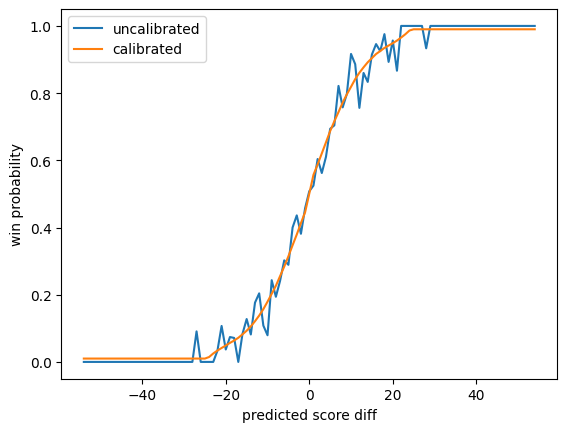

In [149]:
df = pd.DataFrame(
    {"Season": tourney_results_with_features["Season"], 
     "ScoreDiff": oof_score_diffs, 
     "Outcome": tourney_results_with_features["Outcome"], 
     "Category": tourney_results_with_features["Category"],
     "CalibratedPred" : oof_probs
     }
)
df["ScoreDiff"] = df["ScoreDiff"].astype(int)

predictions_df = df.groupby("ScoreDiff")[["Outcome","CalibratedPred"]].mean().reset_index()

plt.figure()
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["Outcome"], label="uncalibrated")
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["CalibratedPred"], label="calibrated")
plt.xlabel("predicted score diff")
plt.ylabel("win probability")
plt.show()

### 2. Classification on Outcome
To predict the probability of winning of a team against the other, we will now do classification, considering the Outcome column as a ground truth.  

In [150]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# CONFIG

FEATURE_COLS = minimal_raw_features
TARGET_COL = 'Outcome'   # 1 = T1 wins, 0 = T1 loses
TARGET_SEASON   = 2025

SEASONS = sorted(tourney_results_with_features['Season'].unique())
SEASONS.remove(TARGET_SEASON)

OPTUNA_TRIALS = 2

# cross-validation with one-season-out

def one_season_out_cv(df, feature_cols, target_col, params, verbose=False):
    """
    Leave-one-season-out CV.
    Returns per-fold log-loss and brier score, plus out-of-fold predictions.
    """
    oof_preds  = np.zeros(len(df))
    fold_scores = []

    for season in SEASONS:
        train = df[df['Season'] != season]
        val   = df[df['Season'] == season]

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_val   = val[feature_cols].values
        y_val   = val[target_col].values

        model = xgb.XGBClassifier(
            **params,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val.index] = preds

        fold_ll = log_loss(y_val, preds)
        fold_bs = brier_score_loss(y_val, preds)
        fold_scores.append({'season': season, 'log_loss': fold_ll, 'brier': fold_bs})

        if verbose:
            print(f"Season {season} — log_loss: {fold_ll:.4f}  brier: {fold_bs:.4f}")

    scores_df = pd.DataFrame(fold_scores)
    if verbose:
        print(f"\nMean log_loss : {scores_df['log_loss'].mean():.4f} ± {scores_df['log_loss'].std():.4f}")
        print(f"Mean brier    : {scores_df['brier'].mean():.4f} ± {scores_df['brier'].std():.4f}")

    return scores_df, oof_preds

# optuna objective (minimizes RMSE + variance to reduce both)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),          # keep shallow — small dataset
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),  # strong regularization
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
    }

    scores_df, _ = one_season_out_cv(
        tourney_results_with_features,
        FEATURE_COLS,
        TARGET_COL,
        params,
    )

    # Penalize high variance across folds, not just mean loss
    mean_ll = scores_df['log_loss'].mean()
    std_ll  = scores_df['log_loss'].std()
    return mean_ll + 0.5 * std_ll   # Optuna minimizes this


# Full pipeline

# optimization

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params

# final CV with best params to get OOF predictions
print(f"\n---------- TRAIN STATS -------------")

scores_df, oof_preds = one_season_out_cv(
    tourney_results_with_features,
    FEATURE_COLS,
    TARGET_COL,
    best_params,
    verbose=True,
)

# train final model on TARGET_SEASON

X_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][FEATURE_COLS].values
y_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][TARGET_COL].values
X_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][FEATURE_COLS].values
y_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][TARGET_COL].values

final_model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
)
final_model.fit(X_train, y_train)

y_pred = final_model.predict_proba(X_test)[:, 1]

ll = log_loss(y_test, y_pred)
bs = brier_score_loss(y_test, y_pred)

print(f"\n---------- TEST STATS -------------")
print(f"Season {TARGET_SEASON} — log_loss: {ll:.4f}  brier: {bs:.4f}")

# FEATURE IMPORTANCE

importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nFeature importances:\n", importance)

  0%|          | 0/2 [00:00<?, ?it/s]


---------- TRAIN STATS -------------
Season 2003 — log_loss: 0.5878  brier: 0.2068
Season 2004 — log_loss: 0.5722  brier: 0.2009
Season 2005 — log_loss: 0.5533  brier: 0.1915
Season 2006 — log_loss: 0.5772  brier: 0.2018
Season 2007 — log_loss: 0.4643  brier: 0.1561
Season 2008 — log_loss: 0.5040  brier: 0.1728
Season 2009 — log_loss: 0.4635  brier: 0.1559
Season 2010 — log_loss: 0.5130  brier: 0.1739
Season 2011 — log_loss: 0.5826  brier: 0.2049
Season 2012 — log_loss: 0.5139  brier: 0.1694
Season 2013 — log_loss: 0.5650  brier: 0.1894
Season 2014 — log_loss: 0.5206  brier: 0.1773
Season 2015 — log_loss: 0.4538  brier: 0.1497
Season 2016 — log_loss: 0.6195  brier: 0.2069
Season 2017 — log_loss: 0.5519  brier: 0.1882
Season 2018 — log_loss: 0.6040  brier: 0.1950
Season 2019 — log_loss: 0.4393  brier: 0.1487
Season 2021 — log_loss: 0.6044  brier: 0.2025
Season 2022 — log_loss: 0.5739  brier: 0.1882
Season 2023 — log_loss: 0.5761  brier: 0.1957
Season 2024 — log_loss: 0.4823  brier: 0.1

Let's see the difference between regression calibrated probability and classification calibrated probability! Looks like the one fit on the spline is more stable.

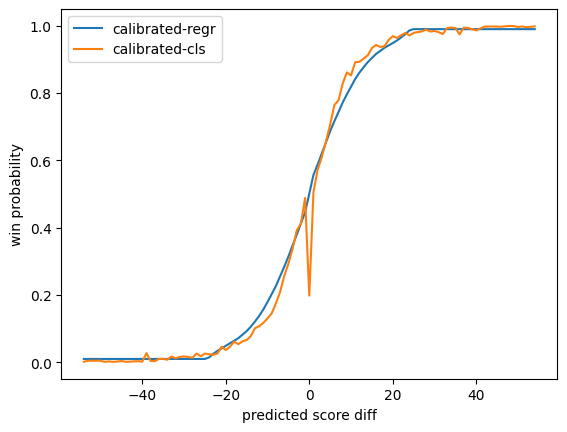

: 

In [151]:
df["ClassificationPred"] = oof_preds
predictions_df = df.groupby("ScoreDiff")[["Outcome","CalibratedPred","ClassificationPred"]].mean().reset_index()

plt.figure()
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["CalibratedPred"], label="calibrated-regr")
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["ClassificationPred"], label="calibrated-cls")
plt.xlabel("predicted score diff")
plt.ylabel("win probability")
plt.show()

### Feature importance with Shapely values?

**NOTE FOR SHARIQ, YOU MIGHT INVESTIGATE THIS**